# Import

In [2]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
from tqdm import tqdm

# NHT Variance

In [27]:
N = 100
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

In [2]:
df = pd.read_csv('populations/MU284_filtered.csv')
cs82 = df['CS82'].values.astype(float)
rmt85 = df['RMT85'].values.astype(float)
ss82 = df['SS82'].values.astype(float)

N = len(df)
n = 10
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
pop = gs.Population(
    coords=rng.rand_coord((N, 2)),
    inclusions=ss82,
    variable=cs82,
    n=4
)

In [3]:
initial_designs = [gs.Design(pop, num_partitions=num_zones) for _ in range(100)]
criteria = gs.criteria.VarNHT()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [4]:
gbfs.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=10,
    num_new_order_nodes=0,
    num_new_exchange_nodes=5,
    num_clusters=2,
    num_zones=1,
    num_changes=2,
    num_zone_changes=1,
    random_pull=True,
    exchange_coef=1.0,
    num_explore=5
)

--- Starting Parallel GBFS: Max Iterations=1000, Batch Size=5, Workers=-1 ---
Initial best criteria value: 498813.2237
Iter     0/1000 | Best: 498813.2237 | Open:   100 | Closed:     0
  [!] New best found at iter 0: 493522.1303 (improved by 5291.0934)
  [!] New best found at iter 1: 488712.5256 (improved by 4809.6047)
  [!] New best found at iter 2: 484458.5789 (improved by 4253.9467)
  [!] New best found at iter 2: 483865.2656 (improved by 593.3133)
  [!] New best found at iter 2: 477902.3794 (improved by 5962.8862)
  [!] New best found at iter 3: 477298.6168 (improved by 603.7626)
  [!] New best found at iter 4: 471269.6208 (improved by 6028.9959)
  [!] New best found at iter 4: 470507.9331 (improved by 761.6878)
  [!] New best found at iter 5: 470199.7306 (improved by 308.2025)
  [!] New best found at iter 5: 466570.5962 (improved by 3629.1344)
  [!] New best found at iter 6: 466013.4427 (improved by 557.1535)
  [!] New best found at iter 7: 465103.5046 (improved by 909.9381)
  [!]

# Spread

## Random Population

In [22]:
N = 200
n = 8
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

<Axes: title={'center': 'FIP Balanced 4-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

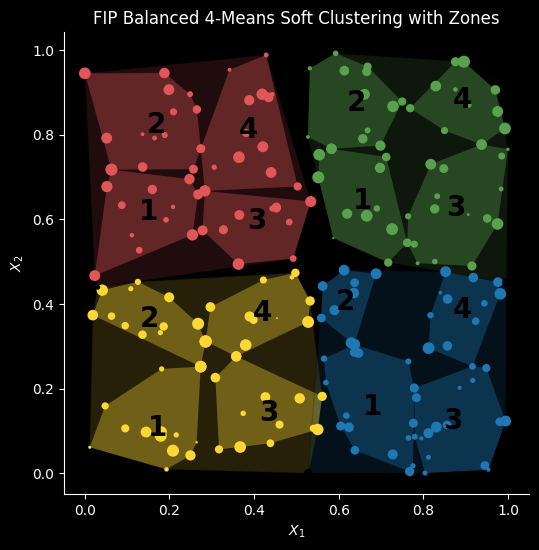

In [35]:
fbn = gs.clustering.IPBalancedOTNMeans(4)
fbn.fit(pop)
fbn.fit_zones(num_zones=(2, 2), mode='sweep_xy')
fbn.plot(mode='soft')

In [36]:
for cluster in fbn.clusters:
    t = 0
    for zone in cluster.zones:
        t += (pop.inclusions[zone.indices] * zone.shares).sum()
    t += pop.inclusions[cluster.floor.index] * cluster.floor.percentage
    t += pop.inclusions[cluster.ceil.index] * cluster.ceil.percentage
    print(round(t, 5))

2.0
2.0
2.0
2.0


In [38]:
order = gs.Order.from_clusters(pop, fbn.clusters)
order.get()

array([[1.43000000e+02, 1.00000000e+00],
       [1.98000000e+02, 1.00000000e+00],
       [1.69000000e+02, 1.00000000e+00],
       [1.71000000e+02, 1.00000000e+00],
       [1.70000000e+01, 1.00000000e+00],
       [7.00000000e+00, 1.00000000e+00],
       [4.80000000e+01, 1.00000000e+00],
       [1.80000000e+01, 1.00000000e+00],
       [4.30000000e+01, 1.00000000e+00],
       [2.20000000e+01, 1.00000000e+00],
       [1.00000000e+02, 1.00000000e+00],
       [1.19000000e+02, 8.15344155e-01],
       [1.19000000e+02, 1.84655845e-01],
       [2.70000000e+01, 1.00000000e+00],
       [1.21000000e+02, 1.00000000e+00],
       [1.40000000e+02, 6.26488586e-01],
       [1.41000000e+02, 1.00000000e+00],
       [1.83000000e+02, 1.00000000e+00],
       [8.50000000e+01, 1.00000000e+00],
       [1.11000000e+02, 1.00000000e+00],
       [8.90000000e+01, 1.00000000e+00],
       [3.70000000e+01, 1.00000000e+00],
       [1.23000000e+02, 1.00000000e+00],
       [1.30000000e+02, 1.00000000e+00],
       [8.100000

## Paper Population

In [39]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())

dict_keys(['swiss', 'RegularPop1000', 'AggregatedPop1027', 'cluster', 'meuse', 'random', 'grid', 'MU284'])


In [40]:
coords = coords_dict['AggregatedPop1027']
probs = probs_dict['AggregatedPop1027']['unequal']
N = len(probs)
n = 20
num_zones = 1
pop = gs.Population(coords, probs, n=n)

In [42]:
initial_designs = []
point_strategies = [
    None, 'lexico_yx', 'dist_from_origin',
    'projection', 'spiral'
]
zone_strategies = [
    None, 'lexico_yx', 'dist_from_origin', 'projection', 'spiral'
]
zone_modes = [
    'sweep_yx'
]
num_zones_cluster = [1]
num_zones_sweep = [(1, 1)]
num_splits = [1]
track = []
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
    product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
):
    if zone_mode == 'cluster':
        list_of_num_zones = num_zones_cluster
    else:
        list_of_num_zones = num_zones_sweep
    for num_zones in list_of_num_zones:
        for _ in range(1):
            fbn = gs.clustering.IPBalancedOTNMeans(n)
            fbn.fit(pop)
            fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
            design = gs.Design.from_order(
                pop,
                order=gs.Order.from_clusters(pop, fbn.clusters, point_strategy, zone_strategy, num_split),
            )
            initial_designs.append(design)
            # print(strategy, zone_mode, num_partitions, design.moran[0])
            track.append((design.moran[0], zone_strategy, point_strategy, zone_mode, num_zones))

100%|██████████| 25/25 [01:10<00:00,  2.83s/it]


In [43]:
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:10]

[(-0.13416790682390953, None, 'lexico_yx', 'sweep_yx', (1, 1)),
 (-0.12962903425099434, None, 'projection', 'sweep_yx', (1, 1)),
 (-0.1294165982753555, None, 'spiral', 'sweep_yx', (1, 1)),
 (-0.12603701380236376, None, 'dist_from_origin', 'sweep_yx', (1, 1)),
 (-0.12543520088202054, None, None, 'sweep_yx', (1, 1)),
 (-0.11260300335605974, 'spiral', 'projection', 'sweep_yx', (1, 1)),
 (-0.11259697515017934, 'spiral', None, 'sweep_yx', (1, 1)),
 (-0.11259697515017934, 'spiral', 'spiral', 'sweep_yx', (1, 1)),
 (-0.11229978836910506, 'spiral', 'lexico_yx', 'sweep_yx', (1, 1)),
 (-0.11156044596323916, 'dist_from_origin', None, 'sweep_yx', (1, 1))]

In [44]:
criteria = gs.search.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [45]:
gbfs.run(
    max_iterations=2000,
    max_open_set_size=1000,
    top_k=1,
    num_new_order_nodes=10,
    num_new_exchange_nodes=0,
    num_clusters=1,
    num_zones=1,
    num_changes=1,
    num_zone_changes=0,
    pull_strategy='default',
    exchange_coef=0.75,
    num_explore=1
)

--- Starting Parallel GBFS: Max Iterations=2000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.1342
Iter     0/2000 | Best: -0.1342 | Open:    25 | Closed:     0
  [!] New best found at iter 0: -0.1343 (improved by 0.0001)
  [!] New best found at iter 0: -0.1348 (improved by 0.0005)
  [!] New best found at iter 1: -0.1350 (improved by 0.0002)
  [!] New best found at iter 2: -0.1352 (improved by 0.0002)
  [!] New best found at iter 3: -0.1357 (improved by 0.0005)
  [!] New best found at iter 4: -0.1357 (improved by 0.0000)
  [!] New best found at iter 5: -0.1358 (improved by 0.0000)
  [!] New best found at iter 5: -0.1358 (improved by 0.0000)
  [!] New best found at iter 5: -0.1358 (improved by 0.0000)
  [!] New best found at iter 6: -0.1360 (improved by 0.0002)
  [!] New best found at iter 8: -0.1361 (improved by 0.0001)
  [!] New best found at iter 9: -0.1363 (improved by 0.0003)
  [!] New best found at iter 10: -0.1365 (improved by 0.0001)
  [!] New best found at iter 

KeyboardInterrupt: 